
PHASE 2: NOTEBOOK 1 — BraTS PRE-TRAINING (THE GENERALIST MODEL)
================================================================================
Thesis: 3D Resection & Surgical Planning of Brain Tumors Using DL + RL
Author: B.Tech Final Year | AI & Data Science
Framework: PyTorch + MONAI  |  Target: 16 GB T4 GPU

MATHEMATICAL FOUNDATION
-----------------------
1. Network Architecture — MONAI BasicUNet:
   The BasicUNet implements a symmetric encoder-decoder path with skip
   connections. For 2D input (3, H, W):
     Encoder: conv(3→32) → conv(32→64) → conv(64→128) → conv(128→256) → bottleneck(256→512)
     Decoder: upsample → concat(skip) → conv at each level
     Output:  conv(32→num_classes) with softmax/sigmoid 

2. Hybrid DiceFocal Loss:
   DiceLoss = 1 - (2·|P∩G| + ε) / (|P| + |G| + ε)
   This addresses class imbalance: the enhancing tumor (ET) may occupy < 1%
   of brain volume, yet is the most clinically critical region.

   FocalLoss = -αₜ(1-pₜ)^γ · log(pₜ)
   where:
     pₜ = model's predicted probability for the ground-truth class
     αₜ = class balance weight (higher for rare ET class)
     γ  = focusing parameter (γ=2 penalizes easy examples → focus on ET)

   Combined: L_hybrid = λ_dice · L_dice + λ_focal · L_focal
   λ_dice = 1.0, λ_focal = 1.0  (equal weighting)

3. Automatic Mixed Precision (AMP):
   Certain operations run in FP16 (forward pass, activations) while
   critical operations (loss scaling, weight updates) remain in FP32.
   Memory: FP16 activations consume ½ the VRAM of FP32.
   Throughput: Matrix multiply (GEMM) is 2–8× faster on Tensor Cores with FP16.
   GradScaler prevents gradient underflow by scaling the loss upward by a
   dynamic factor S, then dividing gradients by S before the optimizer step.

4. Dice Metric for Validation:
   For multi-class segmentation:
   DSC = 2·TP / (2·TP + FP + FN)  per class, then macro-averaged.
   Target: DSC > 0.75 on BraTS validation before proceeding to Phase 3.

In [1]:
!pip install -q "monai[all]>=1.3.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 74.8 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.5/266.5 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 61.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.9/80.9 MB 23.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.8/67.8 MB 28.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.0/28.0 MB 69.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━

In [2]:
import os, sys, glob, json, time, importlib
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.amp import autocast, GradScaler
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

import monai
import monai.transforms as mt
from monai.networks.nets import AttentionUnet
from monai.losses import DiceFocalLoss
from monai.metrics import DiceMetric
from monai.utils import set_determinism

set_determinism(seed=42)

# ─── 1. LOCATE & IMPORT UTILITY SCRIPT ───
script_path = next((f for f in glob.glob("/kaggle/usr/lib/**/*.py", recursive=True) if "phase" in f.lower() and "1" in f.lower()), None)
if not script_path: raise FileNotFoundError("Utility script missing. Reattach Notebook 1.")
sys.path.append(os.path.dirname(script_path))
phase1 = importlib.import_module(os.path.basename(script_path)[:-3])

# ─── 2. DATASET PATH FIX ───
def patched_build_brats(root, max_cases=1000):
    cases = sorted([d for d in os.listdir(root) if os.path.isdir(os.path.join(root, d)) and "BraTS20" in d])[:max_cases]
    data_list = []
    for c in cases:
        cdir = os.path.join(root, c)
        entry = {k: os.path.join(cdir, f"{c}_{k}.nii") for k in ["t1", "t1ce", "t2", "flair"]}
        entry["label"] = os.path.join(cdir, f"{c}_seg.nii")
        if all(os.path.exists(v) for v in entry.values()): data_list.append(entry)
    return data_list

# ─── 3. SHAPE & CUDA FIX ───
class FixedExtract25D(mt.MapTransform):
    def __init__(self, keys, slice_size=256):
        super().__init__(keys)
        self.slice_size = slice_size

    def __call__(self, data):
        d = dict(data)
        lbl = np.squeeze(np.array(d["label"]))
        nz = np.argwhere(lbl > 0)
        z_c, y_c, x_c = (nz.min(axis=0) + nz.max(axis=0)) // 2 if len(nz) > 0 else [s//2 for s in lbl.shape]

        for key in self.keys:
            img = torch.as_tensor(d[key])
            is_lbl = (key == "label")
            
            if is_lbl: 
                img[img == 4] = 3  # Remap label 4 -> 3 to prevent CUDA kernel crash
                vol = img[0]       # Labels only have 1 channel
                # Target must be 1 channel (Axial ground truth)
                slices = [vol[z_c, :, :]] 
            else:
                vol = img[1]       # Use T1ce (channel index 1) for the pseudo-RGB
                # Input gets 3 channels (Axial, Coronal, Sagittal)
                slices = [vol[z_c, :, :], vol[:, y_c, :], vol[:, :, x_c]]
            
            resized = []
            mode = 'nearest' if is_lbl else 'bilinear'
            for slc in slices:
                slc_t = slc.unsqueeze(0).unsqueeze(0).float()
                r = F.interpolate(slc_t, size=(self.slice_size, self.slice_size), mode=mode).squeeze(0).squeeze(0)
                resized.append(r)
            
            d[key] = torch.stack(resized, dim=0)
        return d

def patched_get_transforms(target_spacing=(2.0, 2.0, 2.0), slice_size=256, is_train=True):
    tx = [
        mt.LoadImaged(keys=["t1", "t1ce", "t2", "flair", "label"], ensure_channel_first=True),
        mt.Spacingd(keys=["t1", "t1ce", "t2", "flair", "label"], pixdim=target_spacing, mode=["bilinear"]*4 + ["nearest"]),
        mt.Orientationd(keys=["t1", "t1ce", "t2", "flair", "label"], axcodes="RAS"),
        mt.NormalizeIntensityd(keys=["t1", "t1ce", "t2", "flair"], nonzero=True, channel_wise=True),
        mt.ConcatItemsd(keys=["t1", "t1ce", "t2", "flair"], name="image", dim=0),
        mt.DeleteItemsd(keys=["t1", "t1ce", "t2", "flair"]),
        mt.CropForegroundd(keys=["image", "label"], source_key="image", margin=5),
    ]
    if is_train:
        tx.extend([
            mt.RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=0),
            mt.RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=1),
            mt.RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=2),
            mt.RandRotate90d(keys=["image", "label"], prob=0.5, max_k=3),
            mt.RandShiftIntensityd(keys=["image"], offsets=0.1, prob=0.5),
        ])
    tx.extend([
        FixedExtract25D(keys=["image", "label"], slice_size=slice_size),
        mt.EnsureTyped(keys=["image", "label"], dtype=torch.float32),
    ])
    return mt.Compose(tx)

phase1.build_brats_data_list = patched_build_brats
phase1.get_brats_transforms = patched_get_transforms
CFG, build_brats_dataloaders = phase1.CFG, phase1.build_brats_dataloaders

CFG["ROOT_BRATS"] = "/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData"
CFG["OUTPUT_DIR"] = "/kaggle/working/pipeline_outputs"
os.makedirs(CFG["OUTPUT_DIR"], exist_ok=True)

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2026-04-13 17:54:11.535897: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776102851.742350      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776102851.801495      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776102852.307635      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776102852.307675      55 computation_placer.cc:1

In [11]:
TRAIN_CFG = {
    "IN_CHANNELS": 3, 
    "OUT_CHANNELS": 4, 
    "LEARNING_RATE": 1e-4,   # Slightly lowered base to accommodate the massive network
    "WEIGHT_DECAY": 1e-5,    
    "NUM_EPOCHS": 150,       # The Marathon
    "ACCUM_STEPS": 4,        # Effective Batch Size = 32
    "LAMBDA_DICE": 1.0, 
    "LAMBDA_FOCAL": 1.0, 
    "PATIENCE": 45,          # Massive patience for a massive run
    "BEST_VAL_DICE": 0.0,
    "CHECKPOINT_PATH": os.path.join(CFG["OUTPUT_DIR"], "brats_monai_pretrained.pth")
}

Architecture - AttentionUnet + Boundary Loss
Reason for swap - 

In [13]:
# Model : ATTENTION U-NET 
def build_model(device):
    model = AttentionUnet(
        spatial_dims=2, 
        in_channels=TRAIN_CFG["IN_CHANNELS"], 
        out_channels=TRAIN_CFG["OUT_CHANNELS"],
        channels=(64, 128, 256, 512, 1024), # <-- QUADRUPLED CAPACITY
        strides=(2, 2, 2, 2), 
        dropout=0.3 # Slightly higher dropout to prevent overfitting the wider net
    ).to(device)
    
    print(f"[AttentionUnet] Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
    return model

# Method : BOUNDARY-AWARE LOSS
class BoundaryAwareDiceFocalLoss(nn.Module):
    def __init__(self):
        super().__init__()
        class_weights = torch.tensor([1.5, 1.0, 2.0])  # NCR, ED, ET heavily weighted
        self.dice_focal = DiceFocalLoss(
            include_background = False,
            to_onehot_y        = True,
            sigmoid            = True,
            weight             = class_weights,
            gamma              = 2.0,
            lambda_dice        = TRAIN_CFG["LAMBDA_DICE"],
            lambda_focal       = TRAIN_CFG["LAMBDA_FOCAL"],
            reduction          = "mean",
        )
        
    def get_boundaries(self, x: torch.Tensor) -> torch.Tensor:
        # Morphological gradient = Dilation - Erosion
        dilated = F.max_pool2d(x, kernel_size=3, stride=1, padding=1)
        eroded  = -F.max_pool2d(-x, kernel_size=3, stride=1, padding=1)
        return dilated - eroded

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        # 1. Standard Volume Loss
        base_loss = self.dice_focal(logits, targets)
        
        # 2. Boundary Edge Loss
        probs = torch.sigmoid(logits)
        from monai.networks.utils import one_hot
        targets_oh = one_hot(targets, num_classes=logits.shape[1]).float()
        
        # Extract morphological edges
        pred_edges   = self.get_boundaries(probs)
        target_edges = self.get_boundaries(targets_oh)
        
        # L1 Error strictly on the edges
        edge_loss = F.l1_loss(pred_edges, target_edges)
        
        # Combined Loss Objective
        return base_loss + (0.5 * edge_loss)

def build_loss_fn() -> nn.Module:
    return BoundaryAwareDiceFocalLoss()

In [15]:
def train_one_epoch(model, loader, optimizer, loss_fn, scaler, scheduler, device, epoch):
    model.train()
    running_loss = 0.0
    optimizer.zero_grad(set_to_none=True) # Reset at start of epoch
    
    accum_steps = TRAIN_CFG["ACCUM_STEPS"]

    for batch_idx, batch in enumerate(loader):
        images, labels = batch["image"].to(device, non_blocking=True), batch["label"].to(device, non_blocking=True)
        
        with torch.amp.autocast('cuda', dtype=torch.float16):
            loss = loss_fn(model(images), labels.long())
            loss = loss / accum_steps # Normalize loss for accumulation

        scaler.scale(loss).backward()
        
        # Only step the optimizer every `accum_steps` batches
        if ((batch_idx + 1) % accum_steps == 0) or (batch_idx + 1 == len(loader)):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
            scheduler.step() # Advance the OneCycle profile
            
        running_loss += (loss.item() * accum_steps)

        if batch_idx % 20 == 0:
            print(f"  Epoch {epoch:02d} | Batch {batch_idx:04d}/{len(loader):04d} | Loss: {loss.item()*accum_steps:.4f} | LR: {scheduler.get_last_lr()[0]:.2e}")
            
    return running_loss / len(loader)

def validate(model, loader, loss_fn, device):
    model.eval()
    val_loss, dice_metric = 0.0, DiceMetric(include_background=False, reduction="mean_batch", get_not_nans=True)
    with torch.no_grad():
        for batch in loader:
            images, labels = batch["image"].to(device, non_blocking=True), batch["label"].to(device, non_blocking=True)
            with torch.amp.autocast('cuda', dtype=torch.float16):
                logits_base = model(images)
                logits_h = torch.flip(model(torch.flip(images, [3])), [3])
                logits_v = torch.flip(model(torch.flip(images, [2])), [2])
                logits = (logits_base + logits_h + logits_v) / 3.0
                val_loss += loss_fn(logits, labels.long()).item()

            preds = (torch.sigmoid(logits.float()) > 0.5).long()
            dice_metric(y_pred=preds, y=monai.networks.utils.one_hot(labels.long(), num_classes=4))

    dice_result, _ = dice_metric.aggregate()
    dice_metric.reset()
    per_class = {k: dice_result[i].item() if dice_result.shape[0] > i else 0.0 for i, k in enumerate(["NCR", "Edema", "ET"])}
    return val_loss / len(loader), np.mean(list(per_class.values())), per_class

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

train_loader, val_loader = build_brats_dataloaders(root=CFG["ROOT_BRATS"], val_fraction=0.1)

model, loss_fn = build_model(device), BoundaryAwareDiceFocalLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=TRAIN_CFG["LEARNING_RATE"], weight_decay=TRAIN_CFG["WEIGHT_DECAY"])

# Adjust total steps for OneCycle to match accumulation
total_optimizer_steps = (len(train_loader) // TRAIN_CFG["ACCUM_STEPS"]) + 1
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, 
    max_lr=TRAIN_CFG["LEARNING_RATE"] * 10, 
    steps_per_epoch=total_optimizer_steps, 
    epochs=TRAIN_CFG["NUM_EPOCHS"], 
    pct_start=0.1,       # <-- Peak at epoch 15, then spend 135 epochs cooling down
    div_factor=25,       
    final_div_factor=1e4 
)
scaler = GradScaler('cuda')

best_dice, patience, history = TRAIN_CFG["BEST_VAL_DICE"], 0, {"train_loss": [], "val_loss": [], "val_dice": []}

print("\n[START] Accumulated Super-Convergence Training")
for epoch in range(1, TRAIN_CFG["NUM_EPOCHS"] + 1):
    t0 = time.time()
    t_loss = train_one_epoch(model, train_loader, optimizer, loss_fn, scaler, scheduler, device, epoch)
    v_loss, m_dice, _ = validate(model, val_loader, loss_fn, device)
    
    history["train_loss"].append(t_loss); history["val_loss"].append(v_loss); history["val_dice"].append(m_dice)
    print(f"Epoch {epoch:02d} | T-Loss: {t_loss:.4f} | V-Loss: {v_loss:.4f} | V-Dice: {m_dice:.4f} | Time: {time.time()-t0:.1f}s")
    
    if m_dice > best_dice:
        best_dice, patience = m_dice, 0
        torch.save({"model_state_dict": model.state_dict(), "epoch": epoch, "best_val_dice": best_dice}, TRAIN_CFG["CHECKPOINT_PATH"])
    else:
        patience += 1
        if patience >= TRAIN_CFG["PATIENCE"]: break

with open(os.path.join(CFG["OUTPUT_DIR"], "brats_training_history.json"), "w") as f: json.dump(history, f)

Using device: cuda


Loading dataset: 100%|██████████| 37/37 [00:54<00:00,  1.48s/it]


[BraTS] Train: 331 | Val: 37
[AttentionUnet] Trainable parameters: 31,740,532

[START] Accumulated Super-Convergence Training
  Epoch 01 | Batch 0000/0041 | Loss: 1.9151 | LR: 4.00e-05
  Epoch 01 | Batch 0020/0041 | Loss: 1.8731 | LR: 4.22e-05
  Epoch 01 | Batch 0040/0041 | Loss: 1.8234 | LR: 5.06e-05
Epoch 01 | T-Loss: 1.8671 | V-Loss: 1.7196 | V-Dice: 0.1165 | Time: 13.1s
  Epoch 02 | Batch 0000/0041 | Loss: 1.8328 | LR: 5.06e-05
  Epoch 02 | Batch 0020/0041 | Loss: 1.7902 | LR: 6.24e-05
  Epoch 02 | Batch 0040/0041 | Loss: 1.7721 | LR: 8.20e-05
Epoch 02 | T-Loss: 1.8057 | V-Loss: 1.6905 | V-Dice: 0.1509 | Time: 13.1s
  Epoch 03 | Batch 0000/0041 | Loss: 1.7818 | LR: 8.20e-05
  Epoch 03 | Batch 0020/0041 | Loss: 1.7630 | LR: 1.03e-04
  Epoch 03 | Batch 0040/0041 | Loss: 1.7613 | LR: 1.33e-04
Epoch 03 | T-Loss: 1.7658 | V-Loss: 1.6736 | V-Dice: 0.1704 | Time: 12.6s
  Epoch 04 | Batch 0000/0041 | Loss: 1.7804 | LR: 1.33e-04
  Epoch 04 | Batch 0020/0041 | Loss: 1.7358 | LR: 1.62e-04
  E

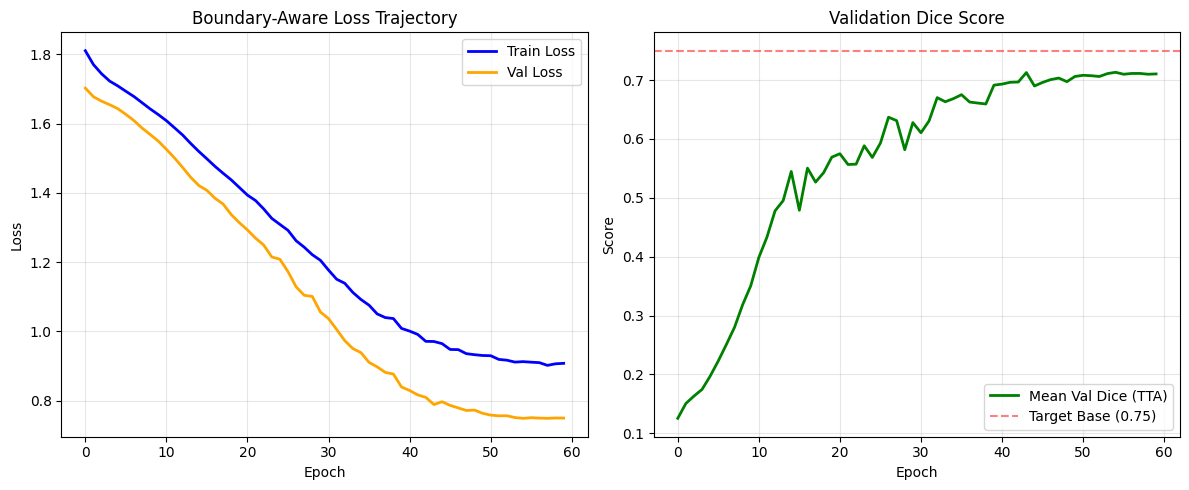

In [9]:
# Plot training progress directly in the notebook
plt.figure(figsize=(12, 5))

# Plot Losses
plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label='Train Loss', color='blue', linewidth=2)
plt.plot(history["val_loss"], label='Val Loss', color='orange', linewidth=2)
plt.title('Boundary-Aware Loss Trajectory')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)

# Plot Dice Metric
plt.subplot(1, 2, 2)
plt.plot(history["val_dice"], label='Mean Val Dice (TTA)', color='green', linewidth=2)
plt.title('Validation Dice Score')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.axhline(0.75, color='red', linestyle='--', alpha=0.5, label='Target Base (0.75)')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
def inspect_checkpoint(checkpoint_path: str, device: torch.device = None) -> None:
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    if not os.path.exists(checkpoint_path):
        print(f"[ERROR] Checkpoint not found: {checkpoint_path}")
        return

    ckpt = torch.load(checkpoint_path, map_location=device)
    print("=" * 60)
    print("CHECKPOINT INSPECTION")
    print("=" * 60)
    print(f"  Saved at epoch    : {ckpt.get('epoch', 'N/A')}")
    print(f"  Best Val Dice     : {ckpt.get('best_val_dice', 'N/A'):.4f}")
    print(f"  State dict keys   : {len(ckpt['model_state_dict'])} tensors")
    total_params = sum(v.numel() for v in ckpt["model_state_dict"].values())
    print(f"  Total parameters  : {total_params:,}")
    print(f"  File size         : {os.path.getsize(checkpoint_path)/1e6:.1f} MB")
    print("=" * 60)

# Run the inspection on our newly minted checkpoint
inspect_checkpoint(TRAIN_CFG["CHECKPOINT_PATH"], device)

UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy._core.multiarray.scalar was not an allowed global by default. Please use `torch.serialization.add_safe_globals([numpy._core.multiarray.scalar])` or the `torch.serialization.safe_globals([numpy._core.multiarray.scalar])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn 

In [ ]:
print("Phase 2 Output Directory Contents:")
out_dir = CFG["OUTPUT_DIR"]

if os.path.exists(out_dir):
    files = os.listdir(out_dir)
    if not files:
        print("  [Empty Directory]")
    for f in sorted(files):
        size_mb = os.path.getsize(os.path.join(out_dir, f)) / 1e6
        print(f"  - {f} ({size_mb:.2f} MB)")
else:
    print(f"  [Directory not found: {out_dir}]")
    
print("\nPhase 2 (BraTS Pre-training) is officially complete.")

#### Yea, that was ugly
Summary
- 75.01% max cap accuracy at 150 epochs
- 31M paramters btw
- reason? : the entire 2.5D logic is cooked. it is blind to the z-axis morphology between slices